# CS106 - Sesión 10 | Notebook 47: Curvas de Kaplan-Meier 📉

La **Estimación de Kaplan-Meier** es el método no paramétrico más utilizado en la literatura médica para calcular la probabilidad de supervivencia (o de mantenerse libre de un evento) a lo largo del tiempo.

### ¿Cómo leer la curva?
* **Eje Y:** Representa la probabilidad acumulada de estar libre del evento (va de 1.0 a 0.0).
* **Los escalones:** Cada caída vertical representa la ocurrencia de una hospitalización o evento en ese día exacto.
* **Las marcas (+):** Indican pacientes censurados (su seguimiento terminó o se retiraron del estudio sin haber presentado el evento).
* **Mediana de Supervivencia:** Es el día exacto en que la curva cruza el 0.5 (50%). Representa el "tiempo promedio" que un grupo tarda en presentar el desenlace.

## 1. Generación de la Curva Global
Utilizaremos la función `survfit()` para analizar a toda nuestra cohorte combinada como un solo grupo. Esto nos permitirá conocer la probabilidad general de la población de mantenerse libre de hospitalización conforme avanzan los días de seguimiento.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 200 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): sexo
dbl (7): paciente_id, edad, estatura_m, peso_kg, glucosa_mgdl, hospitalizado...
lgl (3): diabetes, hipertension, obesidad

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


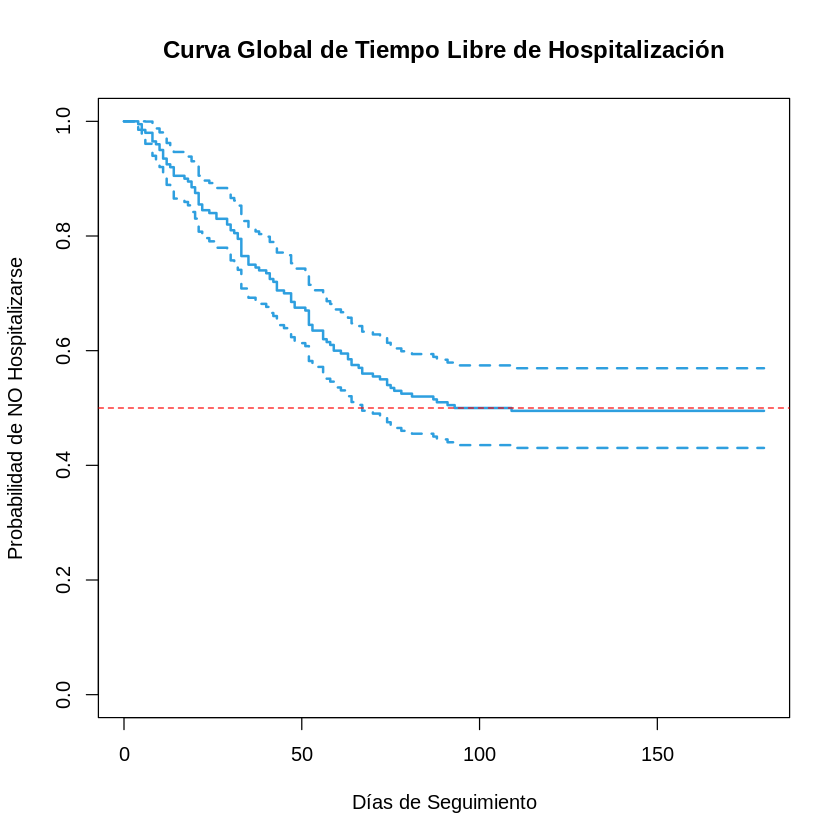

In [ ]:
library(tidyverse)
library(survival)

# Cargamos el archivo de la cohorte
datos <- read_csv("cohorte_survival.csv")

# Ajustamos la curva global usando '~ 1'
ajuste_global <- survfit(Surv(dias_hasta_hospitalizacion, hospitalizado) ~ 1, data = datos)

# Graficamos usando la función nativa de R (Instantánea y sin dependencias pesadas)
plot(ajuste_global,
     conf.int = TRUE,
     col = "#2E9FDF",
     lwd = 2,
     main = "Curva Global de Tiempo Libre de Hospitalización",
     xlab = "Días de Seguimiento",
     ylab = "Probabilidad de NO Hospitalizarse")

# Dibujamos una línea roja discontinua en el 50% para marcar la referencia de la mediana
abline(h = 0.5, lty = 2, col = "red")

## 2. Comparación Estratificada por Sexo
En la práctica clínica, queremos saber si un factor o característica modifica el tiempo libre de evento. Evaluaremos si el comportamiento de hospitalización difiere entre hombres y mujeres sustituyendo el `~ 1` por `~ sexo`.

Call: survfit(formula = Surv(dias_hasta_hospitalizacion, hospitalizado) ~ 
    sexo, data = datos)

              n events median 0.95LCL 0.95UCL
sexo=Hombre  95     45     NA      72      NA
sexo=Mujer  105     56     74      56      NA
                 item   valor
1     mediana_hombres       0
2     mediana_mujeres      74
3 mejor_supervivencia Hombres
4      censura_visual    TRUE


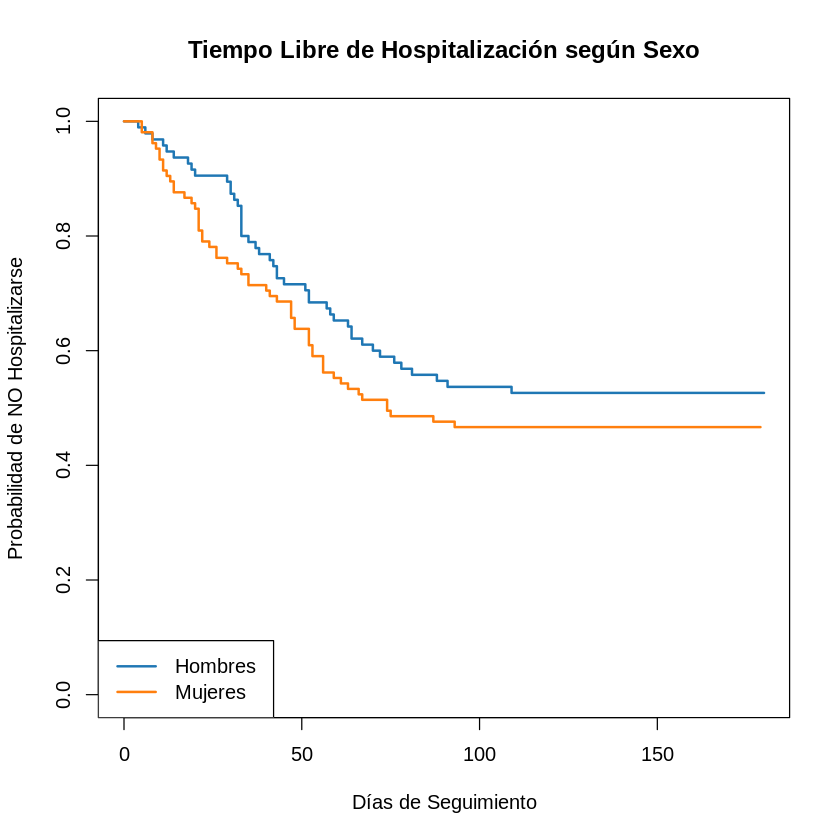

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# Ajustamos las curvas dividiendo la población por la columna 'sexo'
ajuste_sexo <- survfit(Surv(dias_hasta_hospitalizacion, hospitalizado) ~ sexo, data = datos)

# Graficamos ambas curvas asignando colores diferentes nativos
plot(ajuste_sexo,
     col = c("#1f77b4", "#ff7f0e"),
     lwd = 2,
     main = "Tiempo Libre de Hospitalización según Sexo",
     xlab = "Días de Seguimiento",
     ylab = "Probabilidad de NO Hospitalizarse")

# Agregamos una leyenda para identificar visualmente cada curva
legend("bottomleft",
       legend = c("Hombres", "Mujeres"),
       col = c("#1f77b4", "#ff7f0e"),
       lty = 1,
       lwd = 2)

# Imprimimos el reporte del ajuste para extraer las medianas numéricas exactas
print(ajuste_sexo)


# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES REVISANDO LA TABLA IMPRESA) ---

# r1: ¿Cuál es la mediana de tiempo libre de hospitalización para los HOMBRES (días)?
# (Pista: Si la curva no bajó del 50% y R reporta 'NA', escribe 0)
r1_mediana_h <- 0

# r2: ¿Cuál es la mediana de tiempo libre de hospitalización para las MUJERES (días)?
r2_mediana_m <- 74

# r3: ¿Qué grupo demostró mayor estabilidad clínica (curva que se mantiene más alta)?
# (Escribe "Hombres" o "Mujeres")
r3_mejor_grupo <- "Hombres"

# r4: En el gráfico generado, ¿se aprecian las marcas de cruz (+) de censura?
# (Escribe TRUE o FALSE)
r4_presencia_censura <- TRUE


# --- 3. CONSTRUCCIÓN DEL DATA FRAME DE EVALUACIÓN ---
df_respuesta <- data.frame(
  item = c("mediana_hombres", "mediana_mujeres", "mejor_supervivencia", "censura_visual"),
  valor = c(as.character(r1_mediana_h),
            as.character(r2_mediana_m),
            r3_mejor_grupo,
            as.character(r4_presencia_censura))
)

print(df_respuesta)

In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_47(df_respuesta)